## Chapter 3, P7: Building a Predictive Model

This hands-on lab focuses on the practical application of gradient boosting by building, evaluating, and interpreting a gradient boosting model for a classification problem.

We're tasked with predicting the class of wine based on 13 chemical properties.

## Step 1: Loading & Preparing the Data

We'll use pandas to manage our data in a DataFrame, which makes it easier to inspect and manipulate. We will also split the data into training and testing sets to ensure we can evaluate our model's performance on unseen data.


In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns = wine.feature_names)
y = pd.Series(wine.target)

# Display first few rows of the features
print("Features (X):")
print(X.head())

# Display the target variable distribution
print("\nTarget (y) value counts:")
print(y.value_counts())

# Split the data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Features (X):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0    

* The `stratify=y` argument in `train_test_split` ensures that the proportion of each wine class is the same in both the training and testing sets as it is in the original dataset. This prevents imbalances from affecting model training & evaluation.

## Step 2: Training the Gradient Boosting Classifier

We will start with a basic set of parameters. `n_estimators=100` means we will build 100 sequential trees. The `learning_rate=0.1` controls the contribution of each tree, and `max_depth=3` limits the complexity of each individual tree to prevent overfitting. The `random_state` ensures that our results are reproducible.

In [9]:
# Initialise the GradientBoostingClassifier
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit the model to the training data
gbm.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

* The `.fit()` method instantiates the training process. The model makes a random guess prediction for each observation, sequentially trains trees to predict the pseduo-residuals (i.e. negative gradient); attempting to correct the errors of previous trees in the ensemble, and outputs a final ensemble model.

## Step 3: Evalauting Model Performance

We use the `.predict()` method to get the predicted class for each sample in the test set.

In [12]:
# Make predictions on the test set
y_pred = gbm.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")

# Display a detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Model Accuracy: 0.9630

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.89      0.94        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.97        54
weighted avg       0.97      0.96      0.96        54



In [13]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

* The **classification report** reports the precision, recall, and F1-score for each wine class, providing us with a comprehensive view of the model's ability to correct classify samples across all classes.

## Step 4: Interpreting the Model

A good prediction is important, but understanding *why* the model makes certain decisions is often more valuable.  

Let's examine the models feature importance and visualise PDPs.

### Feature Importance

The `feature_importances_` attribute of a trained GBM model provides a score for each feature, indicating how useful it was in constructing the decision trees of the ensemble.  

A higher score means **the feature was used more frequently, in important splits that improve the model's purity.**

In [16]:
import pandas as pd

# Get feature importances
importances = gbm.feature_importances_
feature_names = X.columns

# Create a DataFrame for easier visualisation
feature_importance_df = pd.DataFrame(
    {'feature': feature_names,
     'importance': importances,
    }
).sort_values('importance', ascending = False)

print("Top 10 Feature Importances:")
print(feature_importance_df.head(10))

Top 10 Feature Importances:
                         feature  importance
9                color_intensity    0.286952
12                       proline    0.258546
11  od280/od315_of_diluted_wines    0.188588
6                     flavanoids    0.119016
1                     malic_acid    0.054765
10                           hue    0.034065
2                            ash    0.026324
8                proanthocyanins    0.009209
4                      magnesium    0.008519
0                        alcohol    0.006840


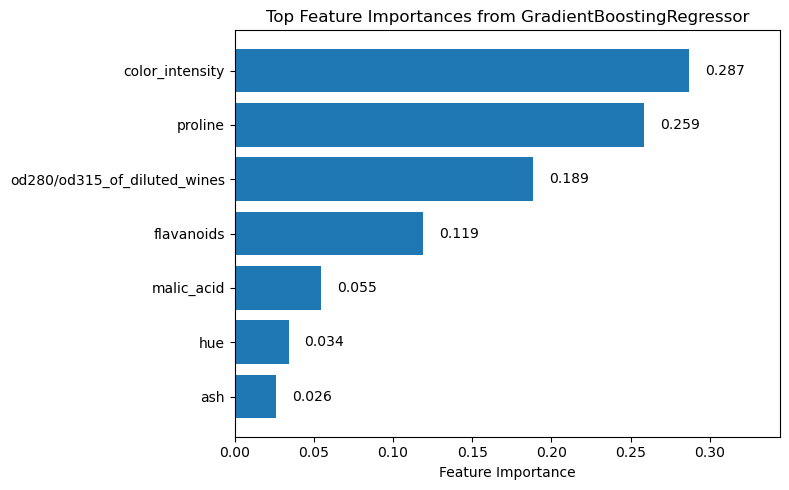

In [17]:
import matplotlib.pyplot as plt

# Take top 7 (or however many you want)
top_df = feature_importance_df.head(7).iloc[::-1]   # reverse for nicer ordering (small → big)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(top_df['feature'], top_df['importance'], color="#1f77b4")

# Annotate values at end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01,             # x-offset
            bar.get_y() + bar.get_height()/2,
            f"{width:.3f}",
            va='center',
            fontsize=10)

ax.set_xlabel("Feature Importance")
ax.set_title("Top Feature Importances from GradientBoostingRegressor")
ax.set_xlim(0, top_df['importance'].max() * 1.2)  # add a little breathing room
plt.tight_layout()
plt.show()

* `color_intensity`, `proline` are the most important drivers of the model's predictions.
* They're features frequently used in important splits that improve the model's impurity.

### Partial Dependence Plots (PDPs)

PDPs bridge the gap between knowing *what* features are important and understanding *how* these important features drive model predictions (e.g., does the feature increase/decrease prediction? does the feature have a linear or complex relationship with the prediction?)

A PDP isolates the effect of one feature while averaging out the effects of all other features.

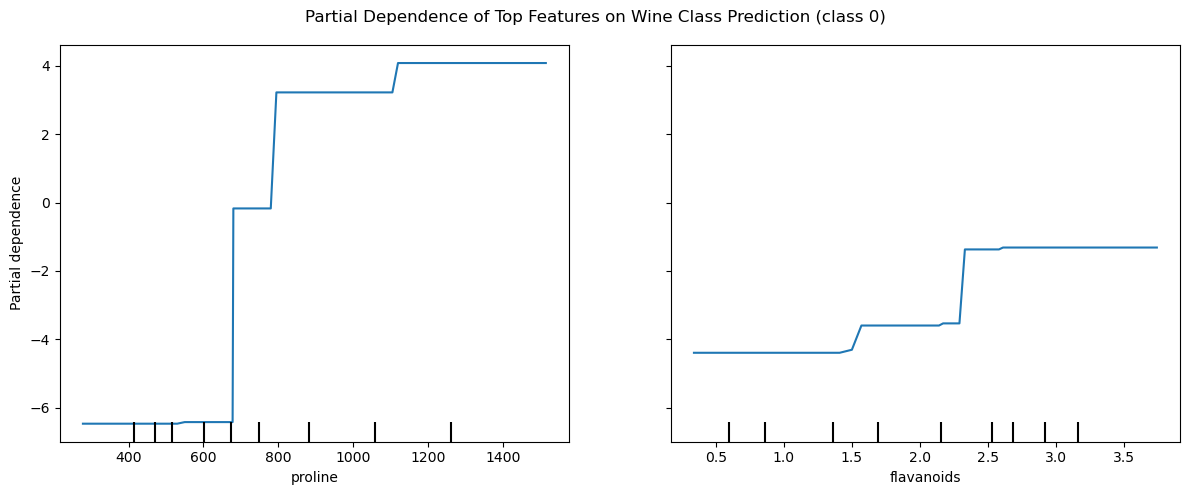

In [21]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# X_train is a DataFrame with columns including 'proline' and 'flavanoids'

fig, ax = plt.subplots(figsize=(12, 5))

display = PartialDependenceDisplay.from_estimator(
    gbm,
    X_train,
    features=['proline', 'flavanoids'],      # column names OK with DataFrame
    feature_names=X_train.columns.tolist(),
    kind='average',                          # PDP, not ICE
    target=0,                                # <--- choose class 0 (or 1 / 2)
    ax=ax,
)

fig.suptitle("Partial Dependence of Top Features on Wine Class Prediction (class 0)")
plt.tight_layout()
plt.show()

* As the `proline` value increases, the probability of belonging to class 0 increases significantly, while the probability of other classes decreases.
* The `flavanoids` shows a positive relationship with class 0 and 1 up to a certain point, after which the effect levels off.

## Summary

We have now gone through the complete lifecycle of a machine learning project using Scikit-Learn's Gradient Boosting implementation (i.e. `GradientBoostingClassifier`).  

We now have a solid foundation for applying this powerful algorithm to datasets and are **well-prepared to explore more advanced, performance-orientated libraries** in the upcoming chapters.